In [8]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_recall_curve

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [9]:
import sys
print(sys.executable)

C:\Users\Shripad\anaconda3\python.exe


In [10]:
!pip install tensorflow

In [11]:
#Loading Benign data
df_benign = pd.read_parquet(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Benign-Monday.parquet")

print("Shape:", df_benign.shape)
print(df_benign["Label"].value_counts())

Shape: (350718, 83)
Label
Benign    350718
Name: count, dtype: int64


In [12]:
#EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

benign = pd.read_parquet(r"c:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Benign-Monday.parquet")
dos = pd.read_parquet(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\DoS-Wednesday.parquet")

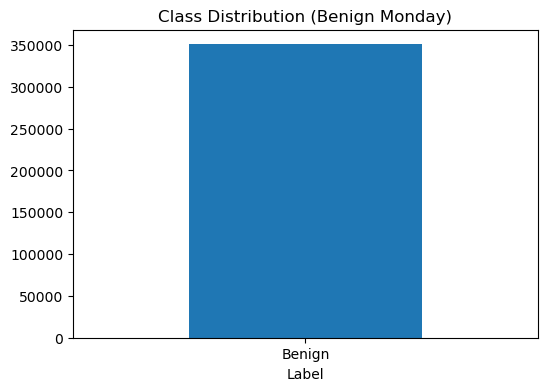

In [13]:
#class distribution
plt.figure(figsize=(6,4))
benign["Label"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Benign Monday)")
plt.xticks(rotation=0)
plt.show()

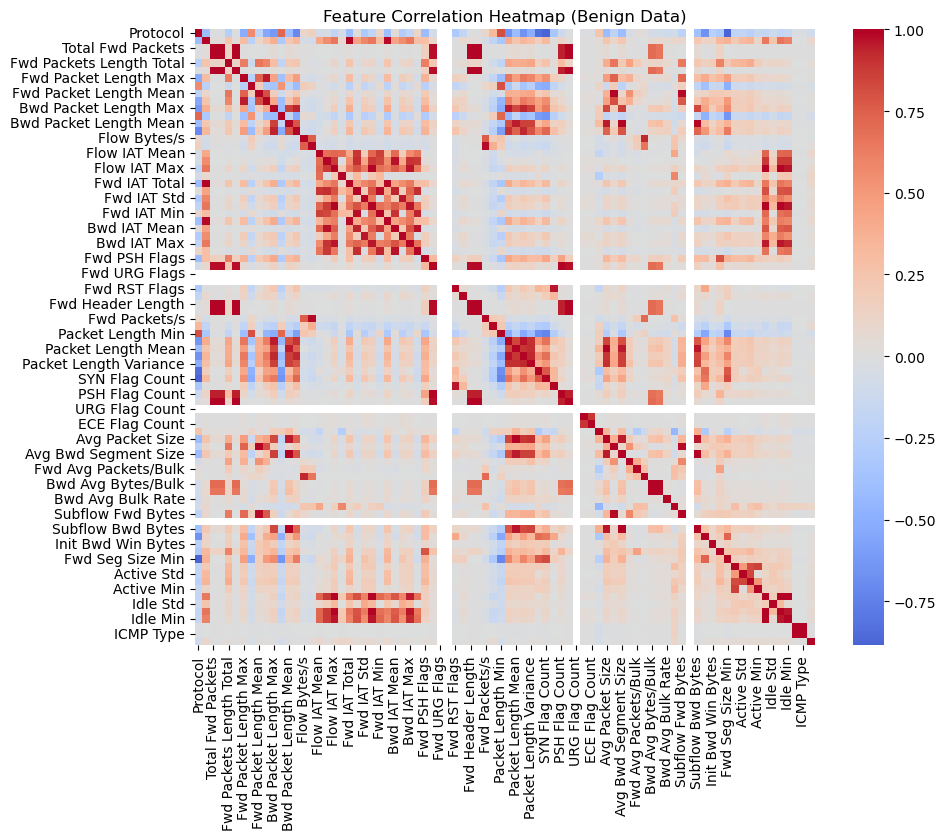

In [14]:
#corelation heat map
sample_benign = benign.sample(20000, random_state=42)

plt.figure(figsize=(10,8))
corr = sample_benign.drop(columns=["Label"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Benign Data)")
plt.show()

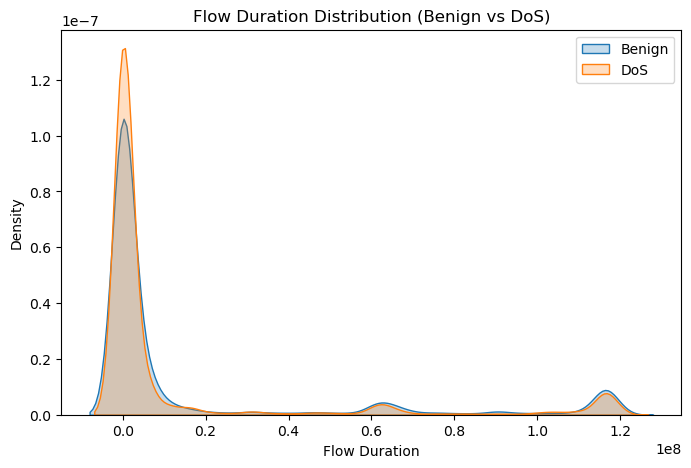

In [15]:
# Feature Distribution comparison
plt.figure(figsize=(8,5))

sns.kdeplot(benign["Flow Duration"], label="Benign", fill=True)
sns.kdeplot(dos["Flow Duration"], label="DoS", fill=True)

plt.legend()
plt.title("Flow Duration Distribution (Benign vs DoS)")
plt.show()

In [16]:
#drop label
X = df_benign.drop(columns=["Label"])

print("Feature shape:", X.shape)

Feature shape: (350718, 82)


In [17]:
#Train / Validation Split
X_train, X_val = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (280574, 82)
Validation shape: (70144, 82)


In [18]:
#Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (280574, 82)


In [19]:
#Define Autoencoder
input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
bottleneck = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(bottleneck)
decoder = Dense(64, activation="relu")(decoder)
output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 82)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           5,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 82)                  │           5,330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,906 (62.13 KB)

 Trainable params: 15,906 (62.13 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#Train Model
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=20,
    batch_size=256,
    validation_data=(X_val_scaled, X_val_scaled),
    shuffle=True
)

Epoch 1/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3529 - val_loss: 0.1582
Epoch 2/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1746 - val_loss: 0.1305
Epoch 3/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1491 - val_loss: 0.0963
Epoch 4/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1169 - val_loss: 0.0975
Epoch 5/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1068 - val_loss: 0.0642
Epoch 6/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0870 - val_loss: 0.0709
Epoch 7/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0935 - val_loss: 0.0642
Epoch 8/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0742 - val_loss: 0.0798
Epoch 9/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0738 - val_loss: 0.0537
Epoch 10/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0758 - val_loss: 0.0404
Epoch 11/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0565 - val_loss: 0.0626
Epoch 12/20
1096/1096 ━━━━━━━━

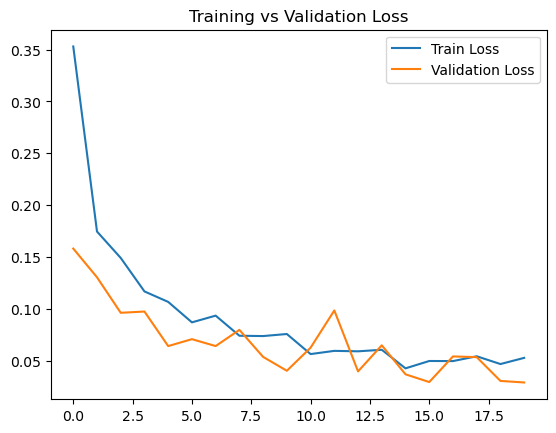

In [21]:
#Plot Loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [22]:
#Reconstruction Error (Validation – Benign)
X_val_pred = autoencoder.predict(X_val_scaled)

reconstruction_error = np.mean(
    np.square(X_val_scaled - X_val_pred),
    axis=1
)

print("Mean error:", np.mean(reconstruction_error))
print("Std error:", np.std(reconstruction_error))
print("Min error:", np.min(reconstruction_error))
print("Max error:", np.max(reconstruction_error))

2192/2192 ━━━━━━━━━━━━━━━━━━━━ 1s 479us/step
Mean error: 0.029100915041519477
Std error: 0.6377509869681061
Min error: 0.00023291243900054866
Max error: 84.42750714815966


In [23]:
threshold = np.percentile(reconstruction_error, 90)
print("Final Threshold (90th percentile):", threshold)

Final Threshold (90th percentile): 0.04178096583280403


In [24]:
#Load Attack Data
df_attack = pd.read_parquet(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Bruteforce-Tuesday.parquet")

X_attack = df_attack.drop(columns=["Label"])

X_attack_scaled = scaler.transform(X_attack)

X_attack_pred = autoencoder.predict(X_attack_scaled)

attack_error = np.mean(
    np.square(X_attack_scaled - X_attack_pred),
    axis=1
)

print("Attack mean error:", np.mean(attack_error))

9596/9596 ━━━━━━━━━━━━━━━━━━━━ 5s 530us/step
Attack mean error: 0.05139217281687712


In [25]:
#Combine & Evaluate
# Create true labels
y_val_true = np.zeros(len(reconstruction_error))   # benign
y_attack_true = np.ones(len(attack_error))         # attack

combined_error = np.concatenate([reconstruction_error, attack_error])
combined_true = np.concatenate([y_val_true, y_attack_true])

# Predictions
combined_pred = combined_error > threshold

print(classification_report(combined_true, combined_pred))

              precision    recall  f1-score   support

         0.0       0.19      0.90      0.31     70144
         1.0       0.84      0.12      0.22    307071

    accuracy                           0.27    377215
   macro avg       0.52      0.51      0.27    377215
weighted avg       0.72      0.27      0.23    377215



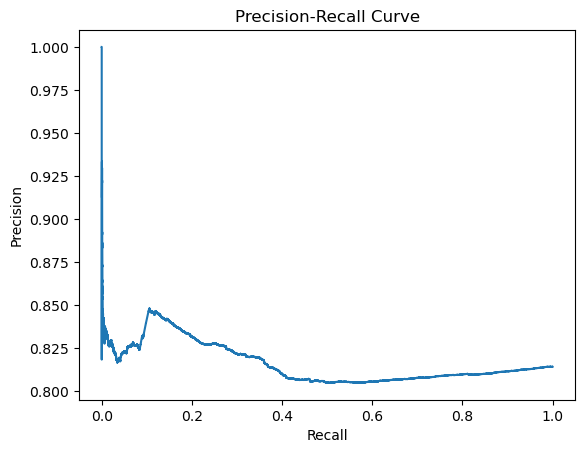

In [26]:
#Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(
    combined_true, combined_error
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

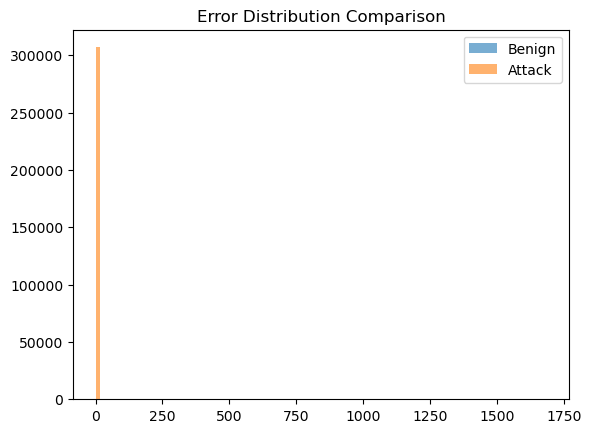

In [27]:
# Error Distribution Comparison
plt.hist(reconstruction_error, bins=100, alpha=0.6, label="Benign")
plt.hist(attack_error, bins=100, alpha=0.6, label="Attack")
plt.legend()
plt.title("Error Distribution Comparison")
plt.show()

In [28]:
#Lowering Threshold
for p in [90, 92, 95, 97, 98, 99]:
    th = np.percentile(reconstruction_error, p)
    preds = combined_error > th
    print(f"\nPercentile {p}")
    print(classification_report(combined_true, preds))


Percentile 90
              precision    recall  f1-score   support

         0.0       0.19      0.90      0.31     70144
         1.0       0.84      0.12      0.22    307071

    accuracy                           0.27    377215
   macro avg       0.52      0.51      0.27    377215
weighted avg       0.72      0.27      0.23    377215


Percentile 92
              precision    recall  f1-score   support

         0.0       0.19      0.92      0.31     70144
         1.0       0.83      0.09      0.16    307071

    accuracy                           0.24    377215
   macro avg       0.51      0.51      0.24    377215
weighted avg       0.71      0.24      0.19    377215


Percentile 95
              precision    recall  f1-score   support

         0.0       0.19      0.95      0.31     70144
         1.0       0.82      0.05      0.10    307071

    accuracy                           0.22    377215
   macro avg       0.50      0.50      0.21    377215
weighted avg       0.70      

In [30]:
def evaluate_attack(file_path, attack_name):
    df_attack = pd.read_parquet(file_path)
    
    X_attack = df_attack.drop(columns=["Label"])
    X_attack_scaled = scaler.transform(X_attack)
    
    X_attack_pred = autoencoder.predict(X_attack_scaled, verbose=0)
    
    attack_error = np.mean(
        np.square(X_attack_scaled - X_attack_pred),
        axis=1
    )
    
    # Combine with benign validation
    y_val_true = np.zeros(len(reconstruction_error))
    y_attack_true = np.ones(len(attack_error))
    
    combined_error = np.concatenate([reconstruction_error, attack_error])
    combined_true = np.concatenate([y_val_true, y_attack_true])
    
    combined_pred = combined_error > threshold
    
    print(f"\n===== {attack_name} =====")
    print("Attack Mean Error:", np.mean(attack_error))
    print(classification_report(combined_true, combined_pred))

In [31]:
evaluate_attack(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Bruteforce-Tuesday.parquet", "Bruteforce Tuesday")
evaluate_attack(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\DoS-Wednesday.parquet", "DoS Wednesday")
evaluate_attack(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Infiltration-Webattacks-Thursday.parquet", "Thursday Attacks")
evaluate_attack(r"C:\Users\Shripad\Desktop\Sem 6\Data Science\project\data set\Portscan-DDos-Botnet-Friday.parquet", "Friday Attacks")


===== Bruteforce Tuesday =====
Attack Mean Error: 0.05139217281687712
              precision    recall  f1-score   support

         0.0       0.19      0.90      0.31     70144
         1.0       0.84      0.12      0.22    307071

    accuracy                           0.27    377215
   macro avg       0.52      0.51      0.27    377215
weighted avg       0.72      0.27      0.23    377215


===== DoS Wednesday =====
Attack Mean Error: 0.48414147649171685
              precision    recall  f1-score   support

         0.0       0.19      0.90      0.31     70144
         1.0       0.97      0.43      0.59    477871

    accuracy                           0.49    548015
   macro avg       0.58      0.66      0.45    548015
weighted avg       0.87      0.49      0.56    548015


===== Thursday Attacks =====
Attack Mean Error: 0.45162564125959415
              precision    recall  f1-score   support

         0.0       0.20      0.90      0.33     70144
         1.0       0.82      0.

In [32]:
results_summary = pd.DataFrame({
    "Attack Type": ["Bruteforce", "DoS", "Thursday", "Friday"],
    "Recall": [0.12, 0.43, 0.12, 0.33],
    "Precision": [0.84, 0.97, 0.82, 0.95]
})

results_summary

,Attack Type,Recall,Precision
0,Bruteforce,0.12,0.84
1,DoS,0.43,0.97
2,Thursday,0.12,0.82
3,Friday,0.33,0.95


In [34]:
autoencoder.save("autoencoder_model.keras")

import joblib
joblib.dump(scaler, "scaler.pkl")
joblib.dump(threshold, "threshold.pkl")

print("Model and artifacts saved successfully.")

Model and artifacts saved successfully.
